In [1]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import scipy as sp
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [2]:
def subplot_snsheat(data, ax=None, cbar=False, cbar_ax=None):
    from numpy import ndarray
    import seaborn as sns
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()

        plot = sns.heatmap(data, cmap='jet', vmin=0,vmax=0.5,ax=ax, cbar=cbar, cbar_ax=None if not cbar else cbar_ax)
        return plot

    else: pass
    
def subplot_imshow(data, xedges, yedges, ax=None):
    
    from numpy import ndarray
    
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()
            
        im = ax.imshow(data, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                        cmap='jet', aspect='auto')
        #cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'),aspect=10)
        
        return im
    
    else : pass

In [3]:
dir = os.getcwd()
outdir = os.path.join(dir, 'plots/')
if not os.path.exists(outdir):
    os.makedirs(outdir)

In [4]:
dir

'/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/16_reps/SJ9/xtc_files'

In [5]:
pdb = os.path.join(dir,'prot_lig.pdb')
trajectory = os.path.join(dir,'rep.0.xtc')
pdb = md.load_pdb(pdb)
protein_indices = pdb.topology.select('protein')
trajectory = md.load_xtc(trajectory, top=pdb.topology, atom_indices=protein_indices)

In [6]:
trj = trajectory
trj.center_coordinates()
# trj = trj[1:]
top = trj.topology
first_frame = 0
last_frame = trj.n_frames
n_frames=trj.n_frames

nres=[]
for res in trj.topology.residues: nres.append(res.resSeq)
sequence=(' %s' % [residue for residue in trj.topology.residues])
resname=(' %s' % [residue.name for residue in trj.topology.residues])
resindex=(' %s' % [residue.index for residue in trj.topology.residues])
prot_top=top.subset(top.select('protein'))
prot_res=[]
for res in prot_top.residues: prot_res.append(res.resSeq)
prot_resname=(' %s' % [residue.name for residue in prot_top.residues])
residues=len(set(prot_res))

print("** SYSTEM INFO **\n")
print("Number of atoms: %d\n" % trj.n_atoms)
print("Number of residues: %d\n" % len(set(nres)))
print("Number of protein residues: %d\n" % len(set(prot_res)))
print("Number of frames: %d\n" % trj.n_frames)
print("Starting frame: %d\n" % first_frame)
print("Last frame: %d\n" % last_frame)
print("sequence: %s\n" % sequence)
print("residue names: %s\n" % resname)
print("residue index: %s\n" % resindex)

** SYSTEM INFO **

Number of atoms: 807

Number of residues: 48

Number of protein residues: 48

Number of frames: 41652

Starting frame: 0

Last frame: 41652

sequence:  [ARG58, LYS59, TRP60, ASN61, PHE62, ASP63, PHE64, GLN65, ASN66, HIS67, LYS68, PRO69, LEU70, GLU71, GLY72, LYS73, TYR74, GLU75, TRP76, GLN77, GLU78, VAL79, GLU80, LYS81, GLY82, SER83, LEU84, PRO85, GLU86, PHE87, TYR88, TYR89, ARG90, PRO91, PRO92, ARG93, PRO94, PRO95, LYS96, GLY97, ALA98, CYS99, LYS100, VAL101, PRO102, ALA103, GLN104, GLU105]

residue names:  ['ARG', 'LYS', 'TRP', 'ASN', 'PHE', 'ASP', 'PHE', 'GLN', 'ASN', 'HIS', 'LYS', 'PRO', 'LEU', 'GLU', 'GLY', 'LYS', 'TYR', 'GLU', 'TRP', 'GLN', 'GLU', 'VAL', 'GLU', 'LYS', 'GLY', 'SER', 'LEU', 'PRO', 'GLU', 'PHE', 'TYR', 'TYR', 'ARG', 'PRO', 'PRO', 'ARG', 'PRO', 'PRO', 'LYS', 'GLY', 'ALA', 'CYS', 'LYS', 'VAL', 'PRO', 'ALA', 'GLN', 'GLU']

residue index:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 

In [7]:
full_sequence=[]
for residue in trj.topology.residues:
    full_sequence.append(residue)

full_sequence = [str(residue) for residue in full_sequence]

single_letter_code = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLU': 'E', 'GLN': 'Q', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

single_letter_sequence = [single_letter_code[res[:3]] + res[3:] for res in full_sequence]

sequence=[]
for residue in trj.topology.residues:
    sequence.append(str(residue))
len(sequence)

n=5
for i in range (0,len(sequence)):
  if (i % n !=0):
   sequence[i]=''

print(sequence)

['ARG58', '', '', '', '', 'ASP63', '', '', '', '', 'LYS68', '', '', '', '', 'LYS73', '', '', '', '', 'GLU78', '', '', '', '', 'SER83', '', '', '', '', 'TYR88', '', '', '', '', 'ARG93', '', '', '', '', 'ALA98', '', '', '', '', 'ALA103', '', '']


In [8]:
replica0, nrep = 0,16
rep0, nrep = 0,16

temperature = np.array([
    300.0, 305.8, 311.7, 317.8, 323.9, 330.2, 336.6, 343.1,
    349.7, 356.5, 363.4, 370.5, 377.6, 384.9, 392.4, 400.0
])


In [9]:
contact_map_p=json.load(open(dir+'/out_d/p_contact_map.json','r'))

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

def create_subplots(keys, filename, title_prefix):
    nrep = len(keys)
    ncol = 4
    nrow = int(np.ceil(nrep / ncol))

    # Let Matplotlib manage layout and reserve space for the colorbar
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True,
                             figsize=(12, 12), constrained_layout=True)
    axes = np.array(axes).reshape(nrow, ncol).flatten()

    # (Optional) fix color scale across all maps
    # If your contact maps are probabilities, this is appropriate:
    norm = Normalize(vmin=0.0, vmax=1.0)

    for i, key in enumerate(keys):
        if i >= len(axes): break
        ax = axes[i]
        contact_map = contact_map_p[key]
        sns.heatmap(contact_map, ax=ax, cmap='jet', cbar=False,
                    vmin=norm.vmin, vmax=norm.vmax)

        ax.set_xticks(range(48))
        ax.set_xticklabels(sequence, rotation=90, size=8)
        ax.set_yticks(range(48))
        ax.set_yticklabels(sequence, rotation=0, size=8)
        ax.invert_yaxis()
        ax.set_title(f'{title_prefix}-{i}', size=12, pad=3)

    # Hide any unused axes if nrep isn't multiple of ncol
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # One shared, full-height colorbar; constrained_layout will make room
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', shrink=1.0, aspect=30)
    cbar.set_label('Contact Probability', fontsize=12)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath, dpi=600)   # no bbox_inches='tight' needed
    plt.show()


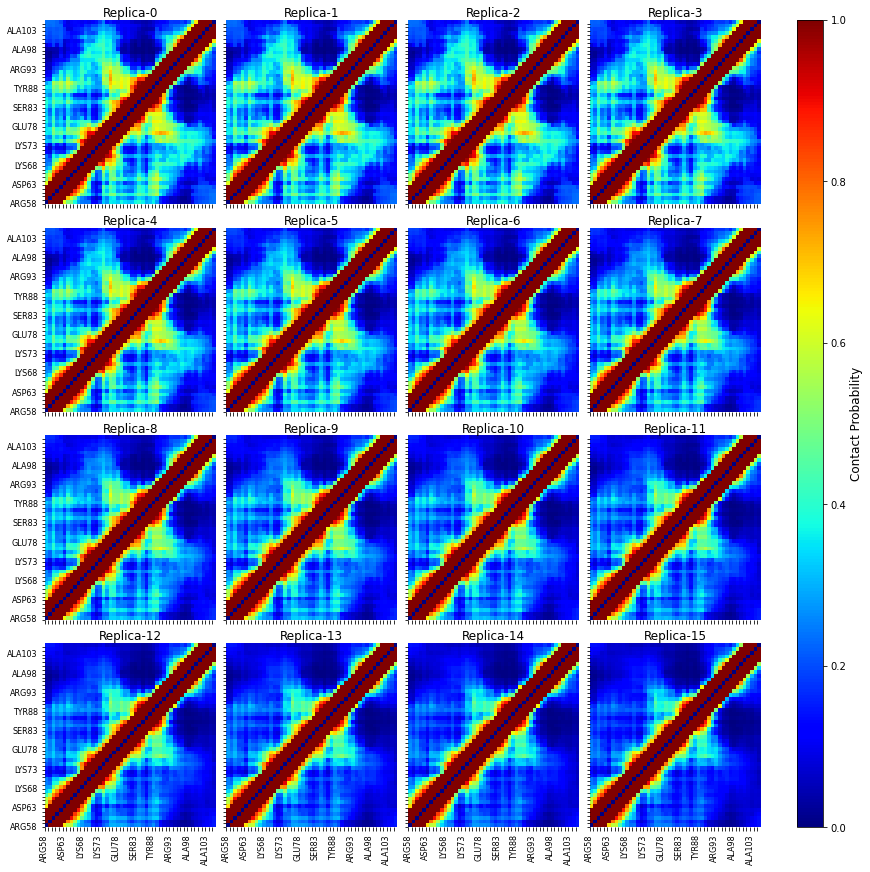

In [11]:

rep_keys = [f'rep:{i}' for i in range(16)]
create_subplots(rep_keys, outdir+'p_contact_maps_rep.png', 'Replica')

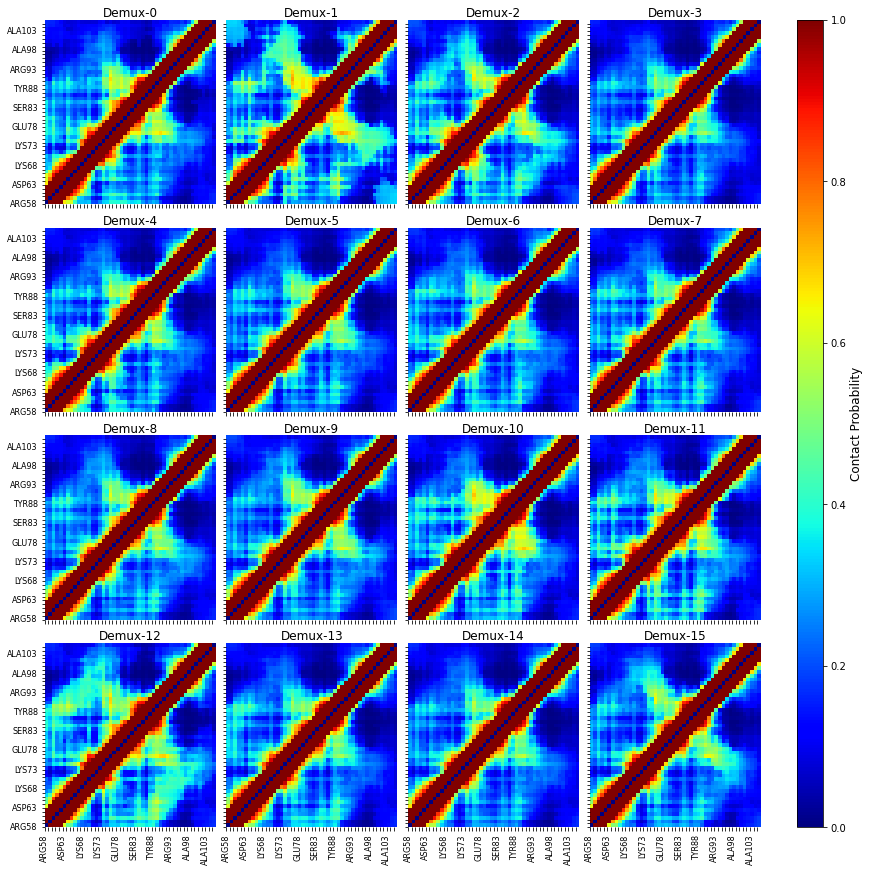

In [12]:
demux_keys = [f'demux:{i}' for i in range(16)]
create_subplots(demux_keys, outdir+'p_contact_maps_demux.png', 'Demux')

In [13]:
contact_map_l=json.load(open(dir+'/out_d/l_contact_map.json','r'))

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

def create_subplots_ligand(keys, filename, title_prefix):
    nrep = len(keys)
    ncol = 4
    nrow = int(np.ceil(nrep / ncol))

    # Let Matplotlib manage layout and reserve space for the colorbar
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True,
                             figsize=(12, 12), constrained_layout=True)
    axes = np.array(axes).reshape(nrow, ncol).flatten()

    # (Optional) fix color scale across all maps
    # If your contact maps are probabilities, this is appropriate:
    norm = Normalize(vmin=0.0, vmax=0.5)

    for i, key in enumerate(keys):
        if i >= len(axes): break
        ax = axes[i]
        contact_map = contact_map_l[key]
        sns.heatmap(contact_map, ax=ax, cmap='jet', cbar=False,
                    vmin=norm.vmin, vmax=norm.vmax)

        ax.set_xticks(range(48))
        ax.set_xticklabels(sequence, rotation=90, size=8)
        ax.set_yticks(range(48))
        ax.set_yticklabels(sequence, rotation=0, size=8)
        ax.invert_yaxis()
        ax.set_title(f'{title_prefix}-{i}', size=12, pad=3)

    # Hide any unused axes if nrep isn't multiple of ncol
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # One shared, full-height colorbar; constrained_layout will make room
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', shrink=1.0, aspect=30)
    cbar.set_label('Contact Probability', fontsize=12)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath, dpi=600)   # no bbox_inches='tight' needed
    plt.show()


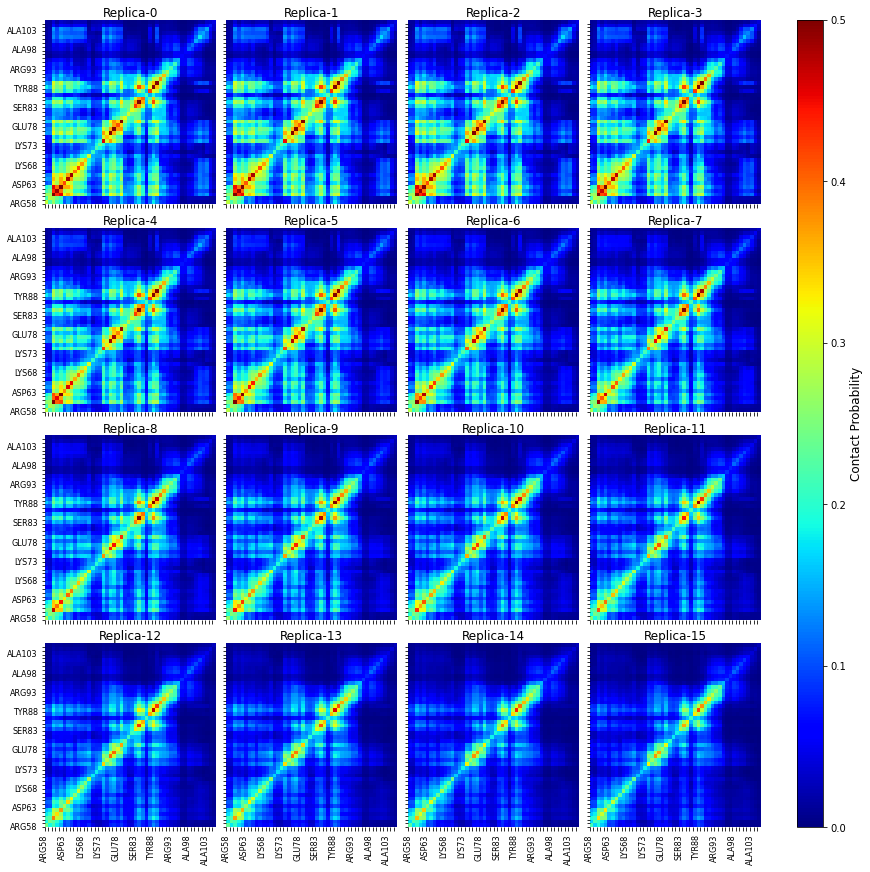

In [15]:
rep_keys = [f'rep:{i}' for i in range(16)]
create_subplots_ligand(rep_keys, outdir+'l_contact_maps_rep.png', 'Replica')

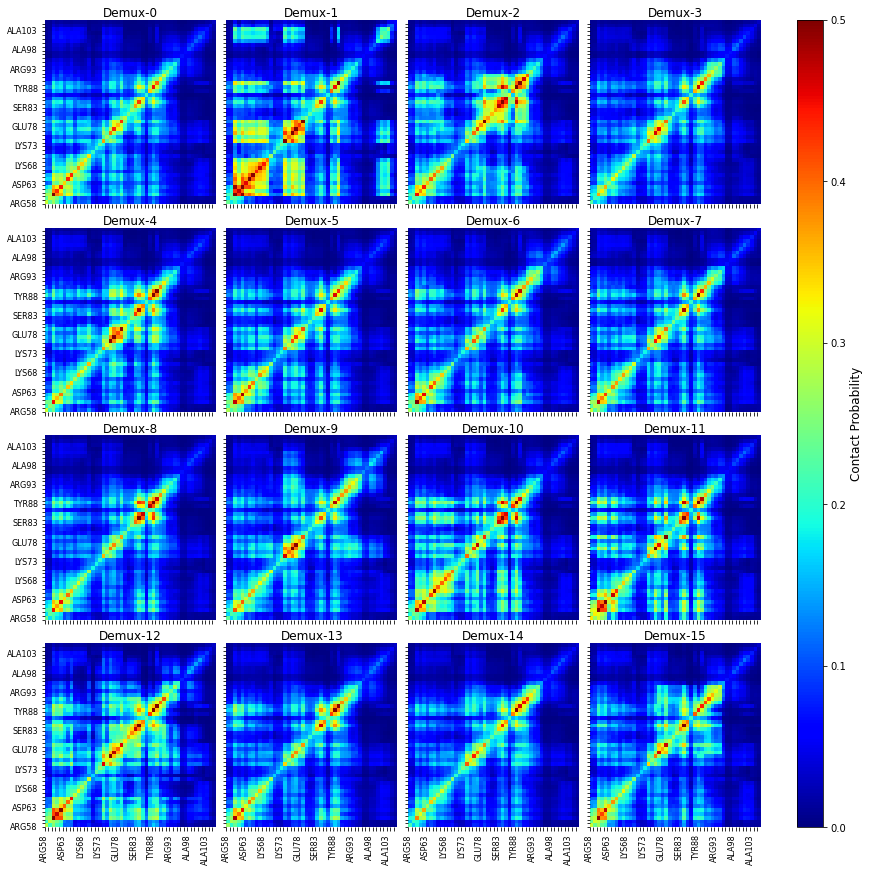

In [16]:
demux_keys = [f'demux:{i}' for i in range(16)]
create_subplots_ligand(demux_keys, 'l_contact_maps_demux.png', 'Demux')

In [17]:
bf_kd=json.load(open(dir+'/out_d/kd.json','r'))

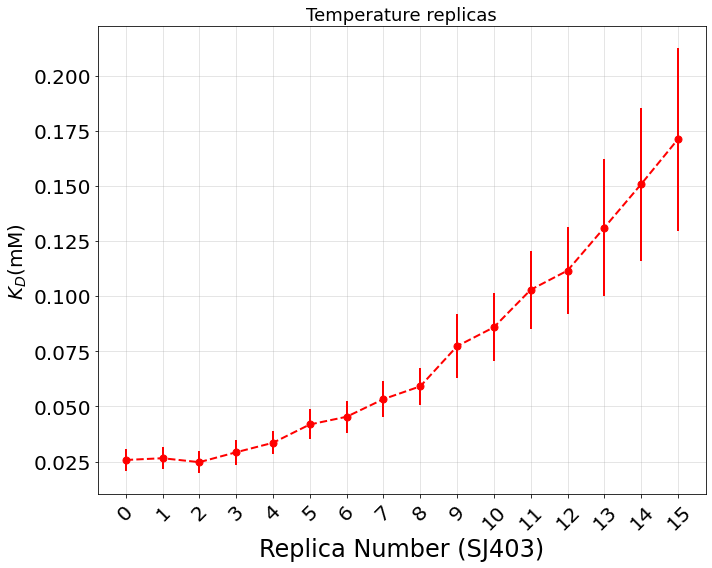

In [18]:
nrep = 16  


kd_values = [bf_kd[f'rep:{i}'][0] for i in range(nrep)]
error_values = [bf_kd[f'rep:{i}'][1] for i in range(nrep)]

fig = plt.figure(figsize=(10, 8))
plt.errorbar(range(nrep), kd_values, yerr=error_values, linestyle='--', marker='o', color='r', lw=2, ms=7)
plt.xticks(range(nrep), [f'{i}' for i in range(nrep)], fontsize=20, rotation=45, fontname='Verdana', color='black')
plt.xlabel('Replica Number (SJ403)', fontsize=24, color='black')

plt.yticks(fontsize=20) 
plt.grid(alpha=0.4)

plt.ylabel(r'$K_{D}$(mM)', fontsize=20)  
plt.title("Temperature replicas", fontsize=18)
plt.tight_layout()

plt.savefig(outdir+'kd_rep.png', dpi=210)
plt.show()

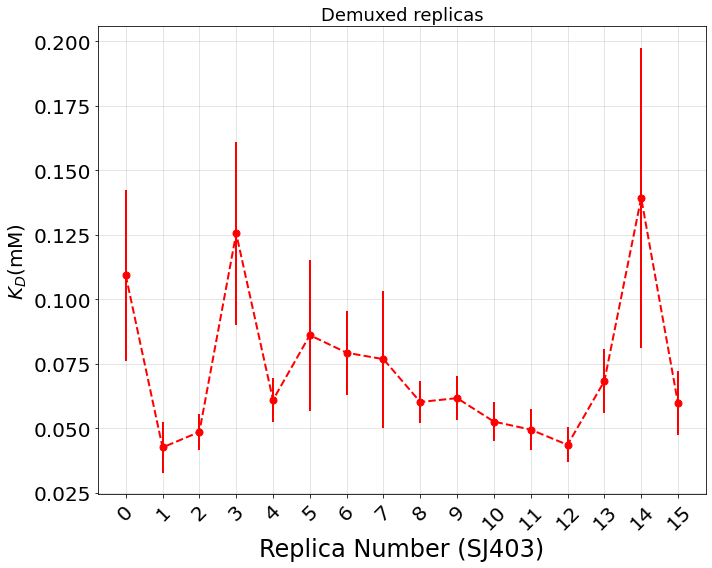

In [19]:
nrep = 16  


kd_values = [bf_kd[f'demux:{i}'][0] for i in range(nrep)]
error_values = [bf_kd[f'demux:{i}'][1] for i in range(nrep)]


fig = plt.figure(figsize=(10, 8))
plt.errorbar(range(nrep), kd_values, yerr=error_values, linestyle='--', marker='o', color='r', lw=2, ms=7)
plt.xticks(range(nrep), [f'{i}' for i in range(nrep)], fontsize=20, rotation=45, fontname='Verdana', color='black')
plt.xlabel('Replica Number (SJ403)', fontsize=24, color='black')

plt.yticks(fontsize=20) 
plt.grid(alpha=0.4)

plt.ylabel(r'$K_{D}$(mM)', fontsize=20)  
plt.title("Demuxed replicas", fontsize=18)
plt.tight_layout()

plt.savefig(outdir+'kd_dmx.png', dpi=210)
plt.show()

In [20]:
hc=json.load(open(dir+'/out_d/helix_contant.json','r'))
bsc=json.load(open(dir+'/out_d/sheet_contant.json','r'))
sa=json.load(open(dir+'/out_d/sa.json','r'))
rg=json.load(open(dir+'/out_d/rg.json','r'))

av_contacts = json.load(open(dir+'/out_d/avg_ligand_contacts.json','r'))
hphob = json.load(open(dir+'/out_d/hyphob_interactions_bf.json','r'))
arom = json.load(open(dir+'/out_d/aro_interactions_bf.json','r'))

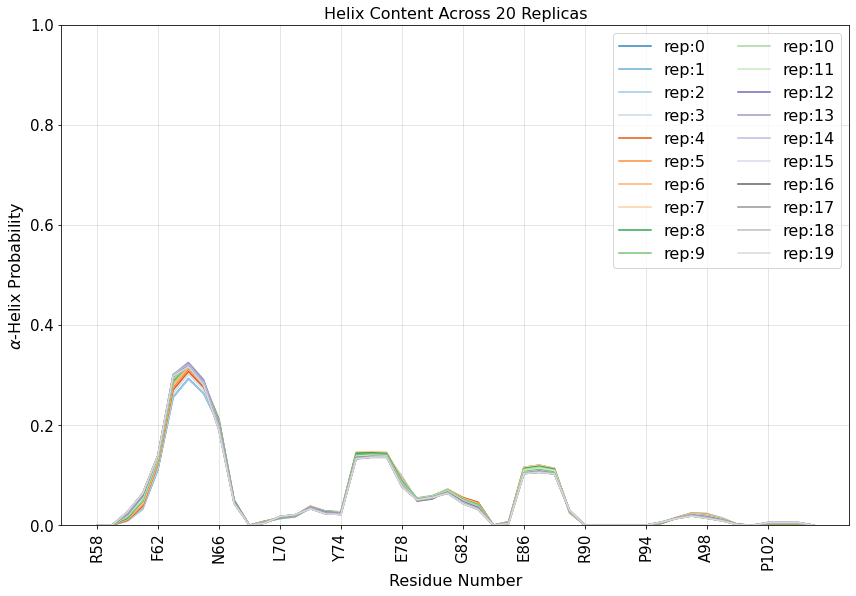

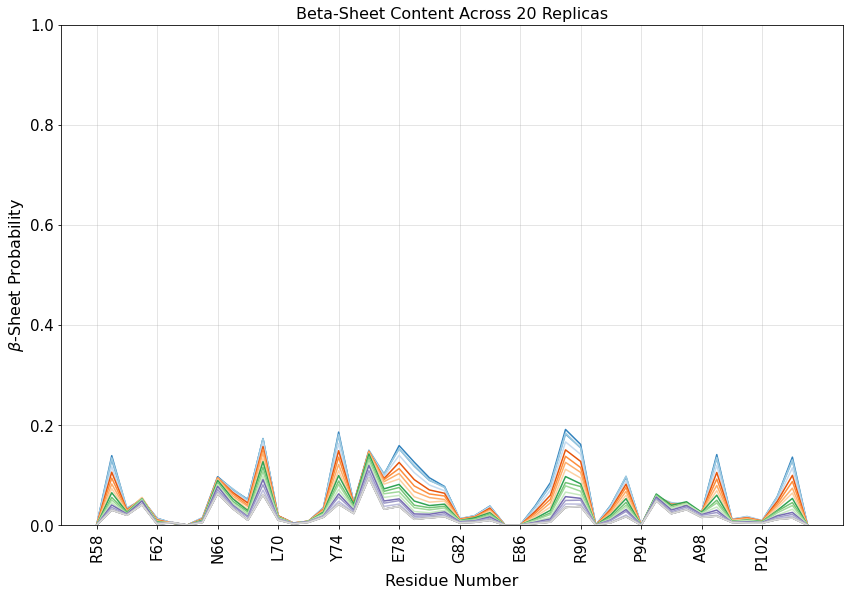

In [21]:
import numpy as np
import matplotlib.pyplot as plt

residues_hc = np.arange(1, 49)

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('rep:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('rep:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True)

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_reps.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
plt.yticks(fontsize=15)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_reps.png', dpi=800)
plt.show()


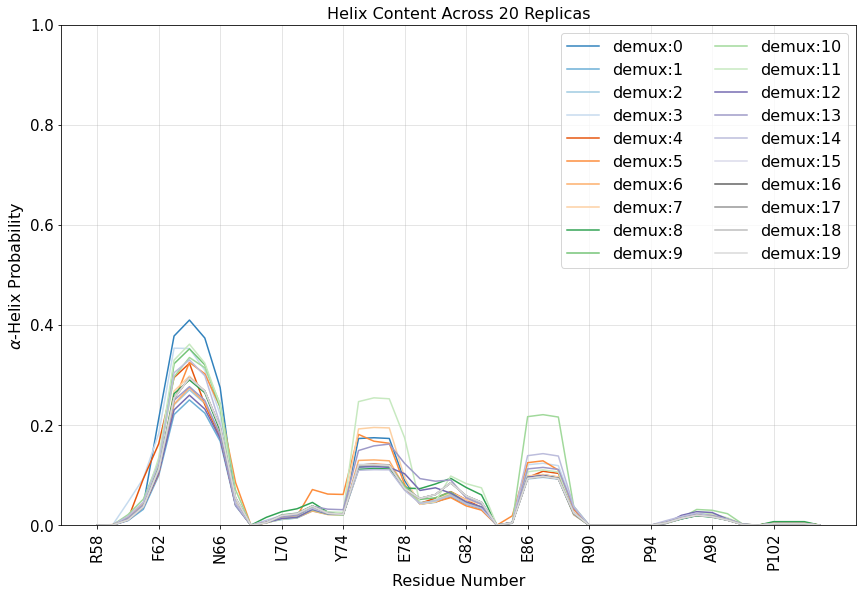

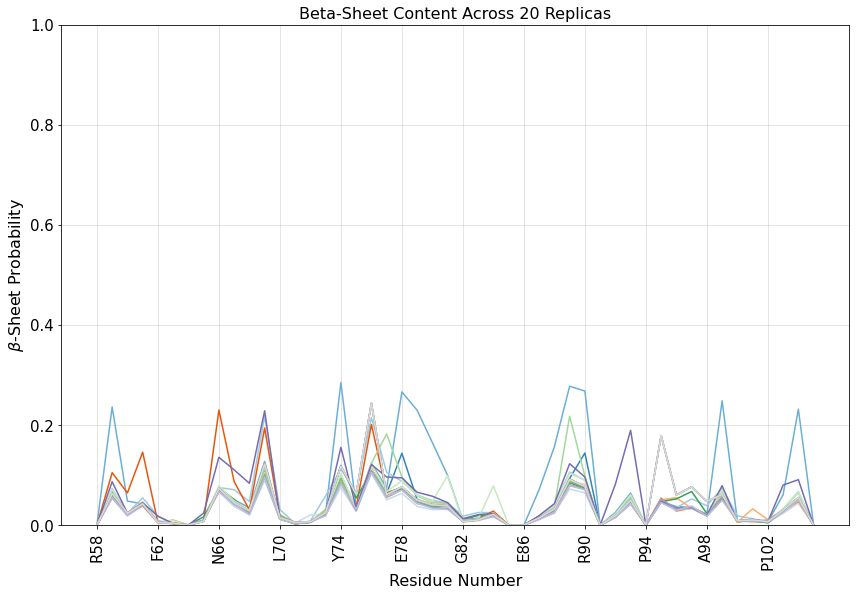

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('demux:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('demux:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True, loc='upper right')

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_dmx.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
plt.yticks(fontsize=15)
spaced_ticks = residues[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_dmx.png', dpi=800)
plt.show()


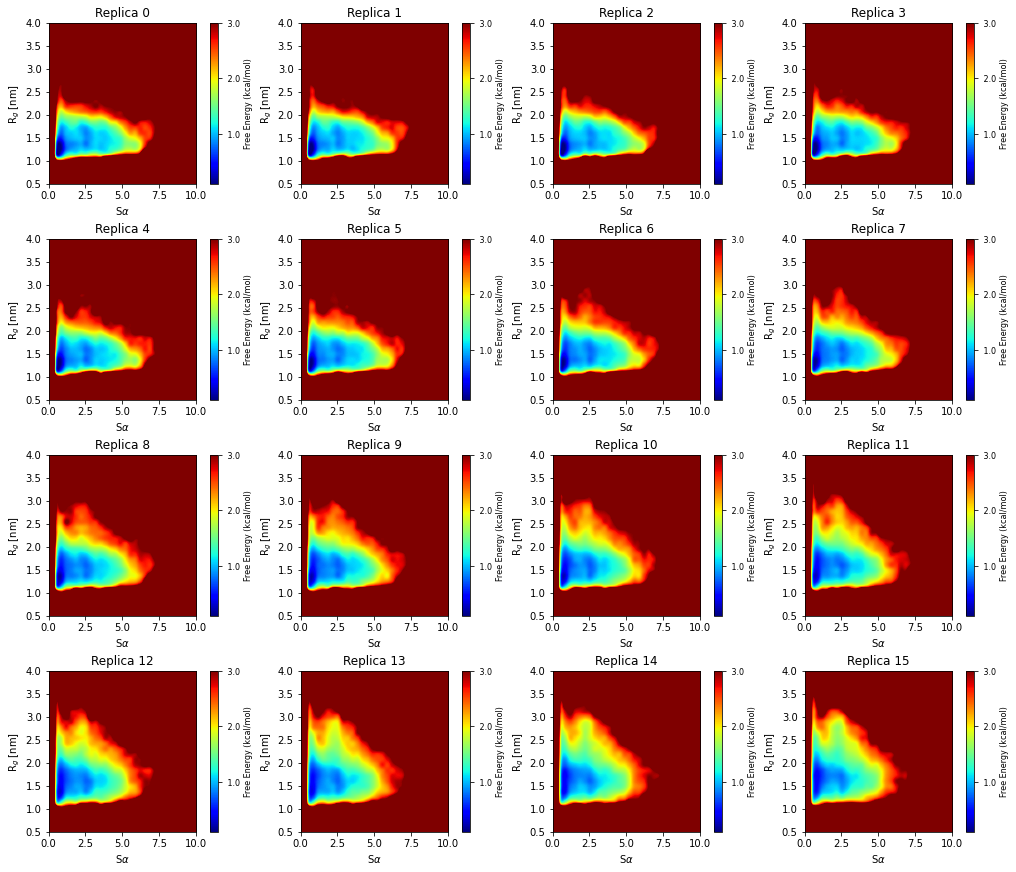

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Rg_vs_Sa_subplot(ax, a, b, T, y0, ymax, x0, xmax, weight=None, title=""):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, bins=30, range=[[y0, ymax], [x0, xmax]], density=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Define the color scale limits
    vmin, vmax = 0.1, 3.0  # Ensures the colorbar is capped at 3 kcal/mol
    cbar_ticks = [0, 1, 2, 3]

    # Plot heatmap with color limits
    im = ax.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                   cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"S$\alpha$", fontsize=10)
    ax.set_ylabel(r"R$_g$ [nm]", fontsize=10)

    # Add colorbar with proper limits
    cbar = plt.colorbar(im, ax=ax, ticks=cbar_ticks, format='% .1f')
    cbar.set_label("Free Energy (kcal/mol)", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(4, 4, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(16):
    rep_key = f'rep:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Replica {i}")

plt.show()

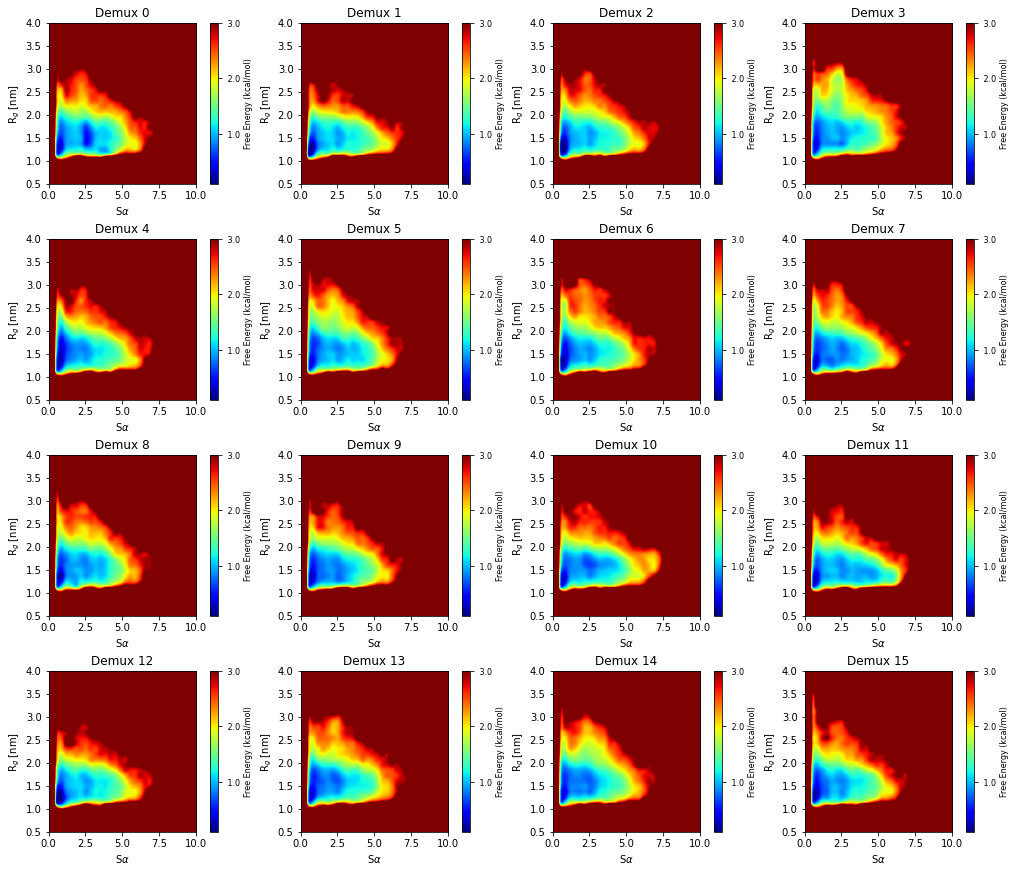

In [24]:
# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(4, 4, figsize=(14, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(16):
    rep_key = f'demux:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Demux {i}")

plt.show()

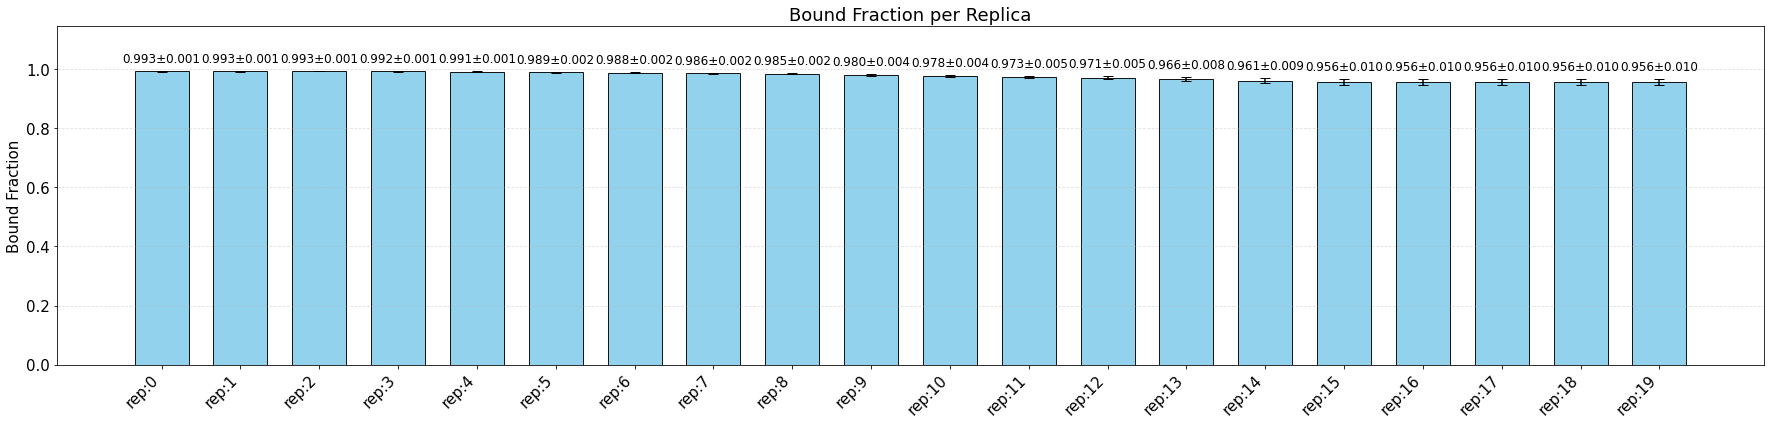

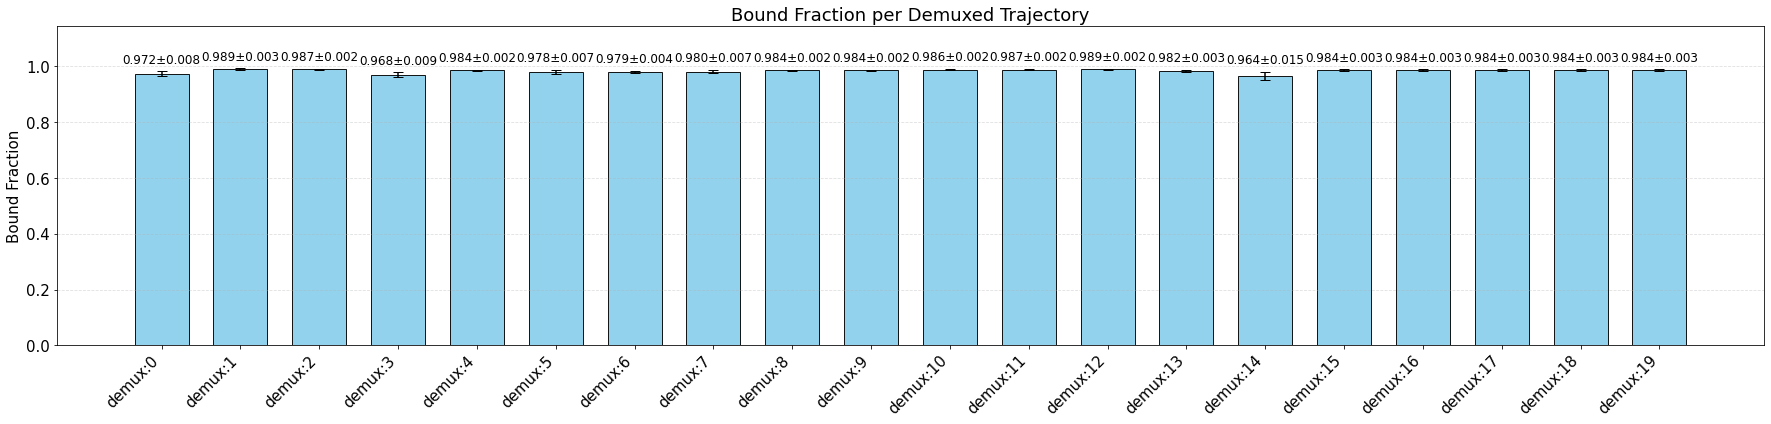

In [25]:
bf = json.load(open(dir+'/out_d/bound_fraction.json','r'))

def plot_bound_fractions(data, prefix, title):
    import matplotlib.pyplot as plt
    import numpy as np

    # Filter and sort keys
    keys = [k for k in data if k.startswith(prefix)]
    keys.sort(key=lambda x: int(x.split(":")[1]))
    values = np.array([data[k][0] for k in keys])
    errors = np.array([data[k][1] for k in keys])

    # Spacing and bar width
    spacing = 1.9
    bar_width = 1.3
    x = np.arange(len(keys)) * spacing

    # Figure setup
    plt.figure(figsize=(spacing * len(keys) * 0.65, 6))
    bars = plt.bar(x, values, yerr=errors, capsize=5, alpha=0.9,
                   width=bar_width, color='skyblue', edgecolor='black')

    # Add labels above the bars
    for i, (v, e) in enumerate(zip(values, errors)):
        label = f"{v:.3f}±{e:.3f}"
        ypos = v + e + 0.02  # Above the bar + error bar
        plt.text(x[i], ypos, label, ha='center', va='bottom',
                 fontsize=12, color='black')

    # Ticks and labels
    plt.xticks(x, keys, rotation=45, ha='right', fontsize=15)
    plt.ylabel("Bound Fraction", fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.ylim(0, max(values + errors) + 0.15)  # add headroom

    plt.show()


# Plot for replica
plot_bound_fractions(bf, prefix='rep', title='Bound Fraction per Replica')

# Plot for demux
plot_bound_fractions(bf, prefix='demux', title='Bound Fraction per Demuxed Trajectory')


In [26]:

def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p

def plot_rg_dist(rg_dict, nbins=50, outdir='.', cmap_name='tab20c', mode='rep', filename=str):


    # Filter keys based on mode
    if mode == 'rep':
        keys = [k for k in rg_dict.keys() if k.startswith('rep:')]
        title = 'Rg Distributions Across Temperature Replicas'
        filename = 'Rg_probabilities_reps.pdf'
    elif mode == 'demux':
        keys = [k for k in rg_dict.keys() if k.startswith('demux:')]
        title = 'Rg Distributions Across Demuxed Replicas'
        filename = 'Rg_probabilities_demux.pdf'
    else:
        raise ValueError("mode must be either 'rep' or 'demux'")

    keys.sort(key=lambda x: int(x.split(':')[1]))

    plt.figure(figsize=(8, 6))
    cmap = plt.cm.get_cmap(cmap_name, len(keys))
    colors = [cmap(i) for i in range(len(keys))]

    for i, key in enumerate(keys):
        x = rg_dict[key]
        p, bc = pmf1d(x, nbins=nbins)
        plt.plot(bc, p, color=colors[i], lw=2, label=key)

    plt.xlabel('Radius of Gyration [nm]', fontsize=14)
    plt.ylabel('Probability Density', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(title='Replica', fontsize=10, title_fontsize=11, ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f"{outdir}/{filename}", bbox_inches='tight')
    plt.show()


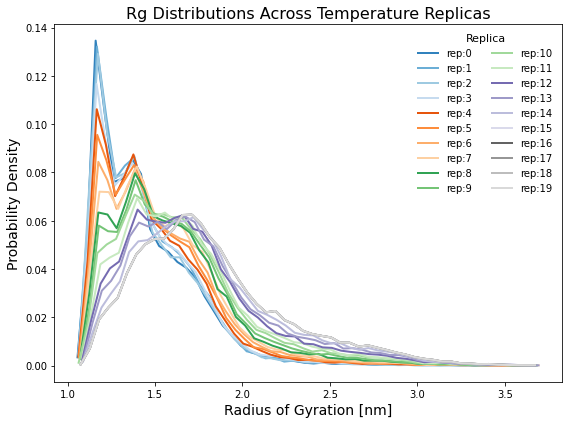

In [27]:
plot_rg_dist(rg, mode='rep', filename='rg_dist_reps.png')

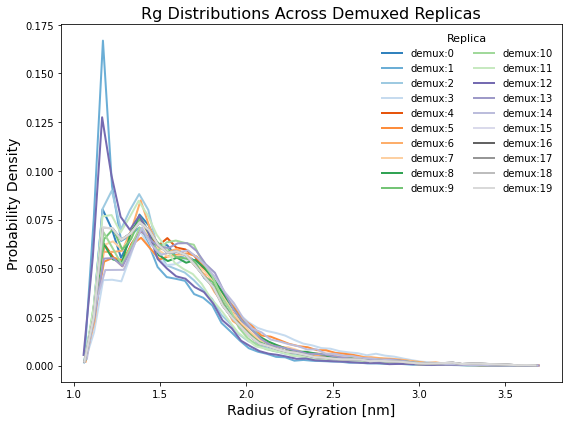

In [28]:
plot_rg_dist(rg, mode='demux', filename='rg_dist_dmx.png')

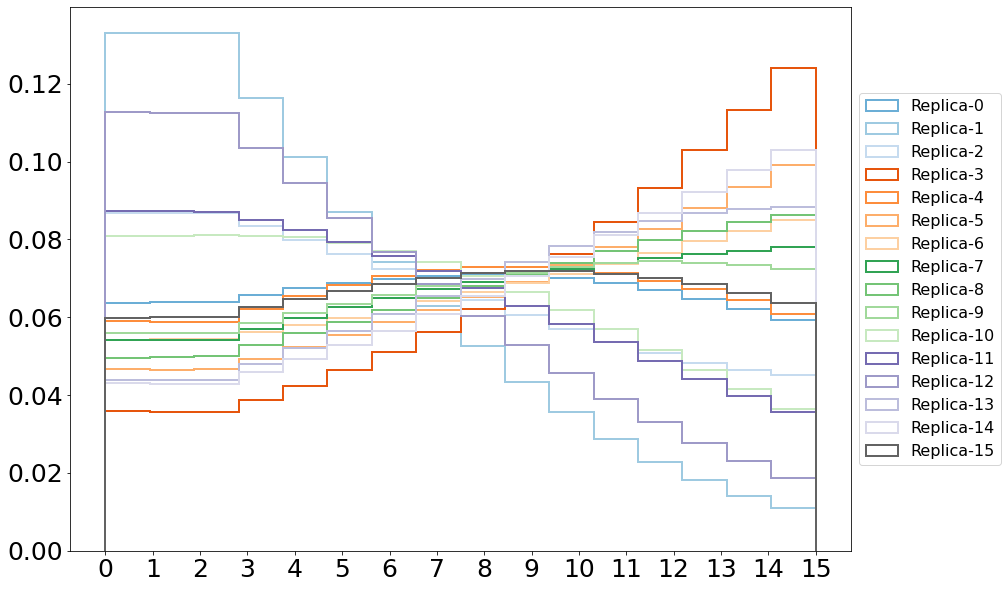

In [29]:
data={}
data['temp'] = np.loadtxt(dir + '/d/replica_temp.xvg', comments=['@','#'])
data['index'] = np.loadtxt(dir + '/d/replica_index.xvg', comments=['@','#'] )


nrep=16

plt.figure(figsize=(14,10))
for i in range(1,nrep+1):
    plt.hist(data['temp'].T[i],histtype='step',density='true',linewidth=2,
             color=plt.cm.tab20c(i),label='Replica-'+str(i-1),bins=nrep)
    
plt.tick_params(labelsize=25)
plt.xticks(range(nrep))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

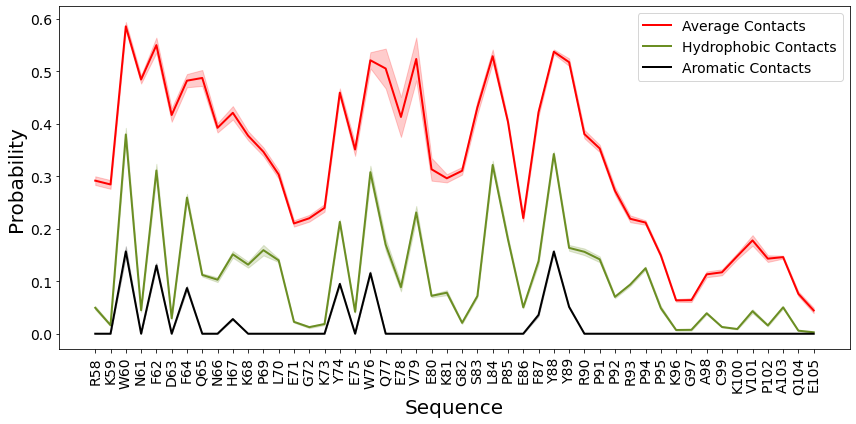

In [30]:
# data_hphob = json.load(open(dir+'/hyphob_interactions_bf.json','r'))
data_hphob = np.asarray(hphob['rep:0'])

#data_arom = json.load(open(dir+'/aro_interactions_bf.json','r'))
data_arom = np.asarray(arom['rep:0'])

#data_avg_con = json.load(open(dir+'/avg_ligand_contacts.json', 'r'))
data_avg_con = np.asarray(av_contacts['rep:0'])




    
    # Extracting data for hydrophobic contacts
residues_hphob = data_hphob[:, 0]
probabilities_hphob = data_hphob[:, 1]
errors_hphob = data_hphob[:, 2]

    # Extracting data for aromatic contacts
residues_arom = data_arom[:, 0]
probabilities_arom = data_arom[:, 1]
errors_arom = data_arom[:, 2]


probabilities_avg_con = data_avg_con[:,1]
errors_avg_con = data_avg_con[:,2]

plt.figure(figsize=(12, 6))
    # Plotting hydrophobic probabilities
    

plt.plot(single_letter_sequence, probabilities_avg_con, linestyle='-', color='red', lw=2, label='Average Contacts')
plt.fill_between(single_letter_sequence, probabilities_avg_con - errors_avg_con, probabilities_avg_con + errors_avg_con, color='red', alpha=0.2)

plt.plot(single_letter_sequence, probabilities_hphob, linestyle='-', color='olivedrab', lw=2, label='Hydrophobic Contacts')
plt.fill_between(single_letter_sequence, probabilities_hphob - errors_hphob, probabilities_hphob + errors_hphob, color='olivedrab', alpha=0.2)

    # Plotting aromatic probabilities
plt.plot(single_letter_sequence, probabilities_arom, linestyle='-', color='black', lw=2, label='Aromatic Contacts')
plt.fill_between(single_letter_sequence, probabilities_arom - errors_arom, probabilities_arom + errors_arom, color='black', alpha=0.2)






plt.xticks(ticks=np.arange(len(single_letter_sequence)), labels=single_letter_sequence, rotation=90, size=14)


plt.yticks(fontsize=14)  


plt.xlabel('Sequence', size=20)
plt.ylabel('Probability', size=20)
# plt.title('Alpha-Helical and Beta-Sheet Content')
plt.legend(fontsize=14, loc='upper right', bbox_to_anchor=(1, 1))


plt.tight_layout()
plt.savefig(outdir + '/contacts_rep0.png', dpi=1200)

plt.show()


In [31]:
nres = len(residues)

In [32]:
import numpy as np

def plot_cmaps(map_data, sequence, title="", filename=""):
    map_data = np.asarray(map_data)      # ✅ convert list -> ndarray
    nres = map_data.shape[0]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)

    im = sns.heatmap(map_data, cmap='jet', ax=ax)
    ax.grid(which='both', alpha=0.5)

    labels = sequence[:nres]
    ax.set_xticks(range(nres))
    ax.set_yticks(range(nres))
    ax.set_xticklabels(labels, rotation=45, fontsize=22)
    ax.set_yticklabels(labels, rotation=45, fontsize=22)

    cbar = im.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label('Residue contact probability', labelpad=35, fontsize=30, rotation=270)

    ax.set_title(title, size=30, pad=20, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath)


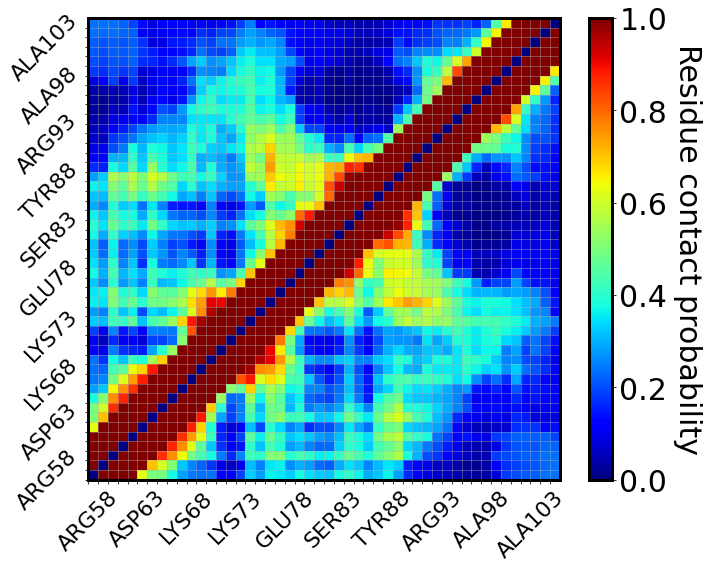

In [33]:
plot_cmaps(contact_map_p['rep:0'], sequence, title='', filename="prot_only_cmap.pdf")


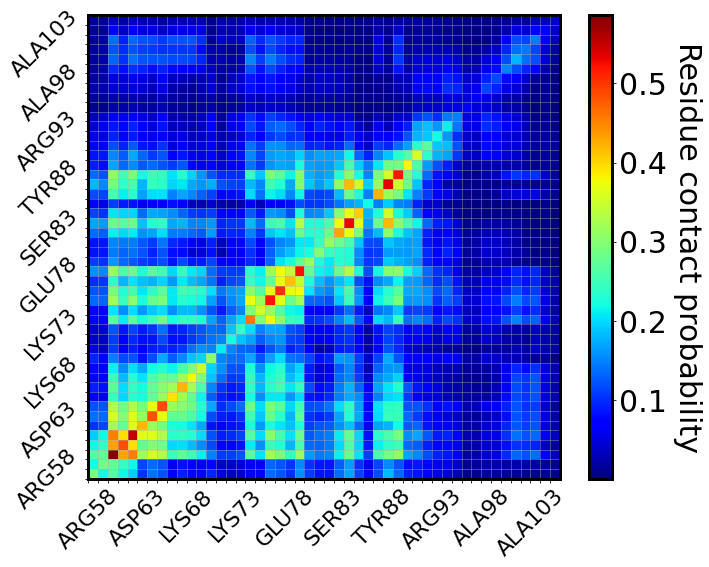

In [34]:
import numpy as np

def plot_lcmaps(map_data, sequence, title="", filename=""):
    map_data = np.asarray(map_data)      # ✅ convert list -> ndarray
    nres = map_data.shape[0]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)

    im = sns.heatmap(map_data, cmap='jet', ax=ax)
    ax.grid(which='both', alpha=0.5)

    labels = sequence[:nres]
    ax.set_xticks(range(nres))
    ax.set_yticks(range(nres))
    ax.set_xticklabels(labels, rotation=45, fontsize=22)
    ax.set_yticklabels(labels, rotation=45, fontsize=22)

    cbar = im.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label('Residue contact probability', labelpad=35, fontsize=30, rotation=270)

    ax.set_title(title, size=30, pad=20, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath)
    


plot_lcmaps(contact_map_l['rep:0'], sequence, title='', filename= "prot_lig_cmap.pdf")

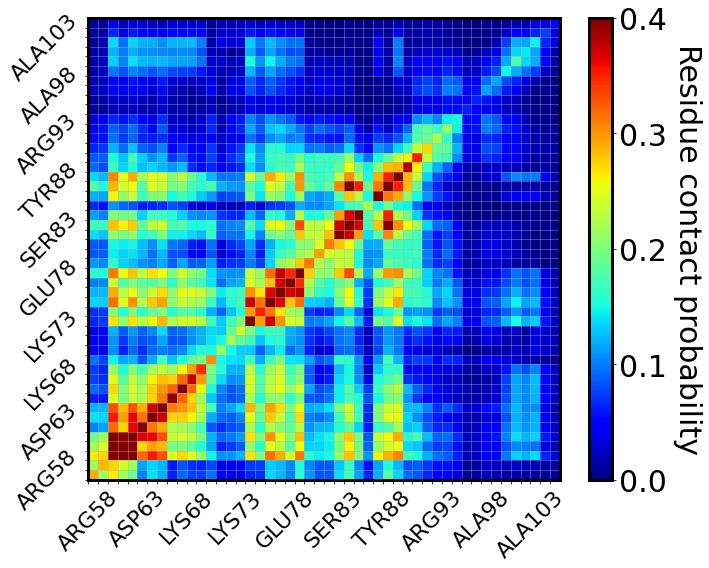

In [35]:
import numpy as np

def plot_lcmaps(map_data, sequence, title="", filename="", vmin=None, vmax=None):
    map_data = np.asarray(map_data)      # convert list -> ndarray
    nres = map_data.shape[0]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)

    # Add vmin / vmax here
    im = sns.heatmap(
        map_data,
        cmap='jet',
        ax=ax,
        vmin=vmin,
        vmax=vmax
    )

    ax.grid(which='both', alpha=0.5)

    labels = sequence[:nres]
    ax.set_xticks(range(nres))
    ax.set_yticks(range(nres))
    ax.set_xticklabels(labels, rotation=45, fontsize=22)
    ax.set_yticklabels(labels, rotation=45, fontsize=22)

    cbar = im.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label(
        'Residue contact probability',
        labelpad=35,
        fontsize=30,
        rotation=270
    )

    ax.set_title(title, size=30, pad=20, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)

    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath)
    plt.show()
    
    
plot_lcmaps(
    contact_map_l['rep:0'],
    sequence,
    filename="prot_lig_cmap.pdf",
    vmin=0,
    vmax=0.4
)

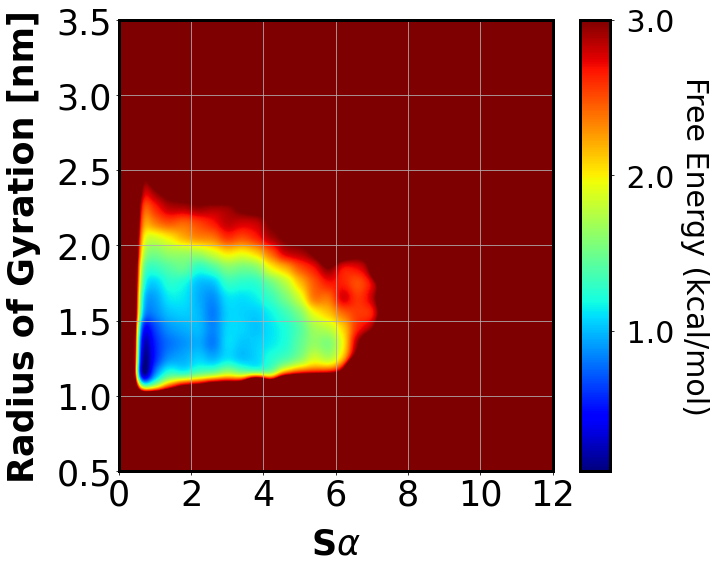

In [36]:
sa_total_rep0 = np.sum(sa['rep:0'], axis=0)


plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3.0

def plot_Rg_vs_Sa(a, b, T, y0, ymax, x0, xmax, scatter_x=None, scatter_y=None, weight=None, title="", filename="plot.pdf"):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], normed=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Create and customize the plot
    fig = plt.figure(figsize=(10, 8))
    plt.scatter(scatter_x, scatter_y, marker='.', c='white', s=800, edgecolors='black', alpha=0.8)
    im = plt.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                    cmap='jet', aspect='auto')
    plt.title(title, fontsize=25, fontweight='bold', pad=20)
    cbar_ticks = [0, 1, 2, 3]
    cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'), aspect=15)
    cb.set_label("Free Energy (kcal/mol)", labelpad=35, fontsize=30, rotation=270)
    imaxes = plt.gca()
    plt.ylabel("Radius of Gyration [nm]", size=35, labelpad=15, fontweight='bold')
    plt.xlabel(r"S$\alpha$", size=35, labelpad=15, fontweight='bold')
    plt.xticks(fontsize=35)
    plt.yticks(fontsize=35)
    plt.grid()
    plt.xlim(0,12)
    plt.axes(cb.ax)
    plt.clim(vmin=0.1, vmax=3.0)
    cb.ax.tick_params(labelsize=30)
    

    file_path = os.path.join(outdir, filename)
    
    
    plt.tight_layout()
    plt.savefig(file_path)
    plt.show()
    
    

plot_Rg_vs_Sa(rg['rep:0'], sa_total_rep0, 300, 0.5, 3.5, 0, 12, scatter_x=None, scatter_y=None, weight=None, title='', filename='unbiased.rg_vs_sa.pdf')

In [37]:
full_sequence

['ARG58',
 'LYS59',
 'TRP60',
 'ASN61',
 'PHE62',
 'ASP63',
 'PHE64',
 'GLN65',
 'ASN66',
 'HIS67',
 'LYS68',
 'PRO69',
 'LEU70',
 'GLU71',
 'GLY72',
 'LYS73',
 'TYR74',
 'GLU75',
 'TRP76',
 'GLN77',
 'GLU78',
 'VAL79',
 'GLU80',
 'LYS81',
 'GLY82',
 'SER83',
 'LEU84',
 'PRO85',
 'GLU86',
 'PHE87',
 'TYR88',
 'TYR89',
 'ARG90',
 'PRO91',
 'PRO92',
 'ARG93',
 'PRO94',
 'PRO95',
 'LYS96',
 'GLY97',
 'ALA98',
 'CYS99',
 'LYS100',
 'VAL101',
 'PRO102',
 'ALA103',
 'GLN104',
 'GLU105']

DSSP array shape: (41652, 48)


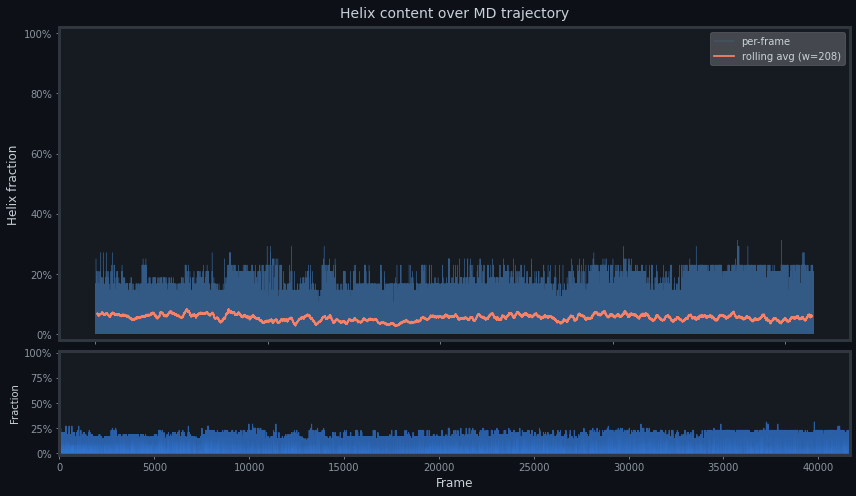

Saved → helix_fraction_over_time.png

Per-residue helix fraction:
Residue  ResID  Helix_%
  ARG58     58      0.0
  LYS59     59      0.0
  TRP60     60      0.9
  ASN61     61      3.3
  PHE62     62     11.1
  ASP63     63     25.7
  PHE64     64     29.2
  GLN65     65     26.4
  ASN66     66     20.2
  HIS67     67      4.6
  LYS68     68      0.0
  PRO69     69      0.8
  LEU70     70      1.5
  GLU71     71      1.8
  GLY72     72      3.4
  LYS73     73      2.4
  TYR74     74      2.2
  GLU75     75     14.2
  TRP76     76     14.2
  GLN77     77     14.0
  GLU78     78      9.6
  VAL79     79      4.8
  GLU80     80      5.2
  LYS81     81      6.8
  GLY82     82      5.3
  SER83     83      4.5
  LEU84     84      0.0
  PRO85     85      0.7
  GLU86     86     11.5
  PHE87     87     12.0
  TYR88     88     11.3
  TYR89     89      2.6
  ARG90     90      0.0
  PRO91     91      0.0
  PRO92     92      0.0
  ARG93     93      0.0
  PRO94     94      0.0
  PRO95     95      0.

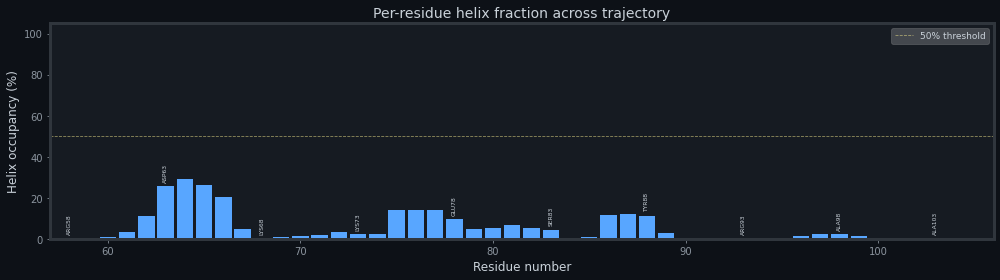

Saved → helix_fraction_per_residue.png

── Summary ──────────────────────────────
Mean helix fraction (all frames):  0.054 ± 0.064
Residues >90% helical:             0
Residues <10% helical:             37
Most helical residue:              PHE64 (29.2%)
Least helical residue:             ARG58 (0.0%)


In [38]:
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── 0. Inputs ────────────────────────────────────────────────────────────────
# Assumes you already have `traj` (mdtraj.Trajectory) and `full_sequence`
# (list of strings like ['ARG58', 'LEU59', ..., 'GLU105']) in your namespace.
# If loading from files, uncomment and adapt:
# traj = md.load('your_traj.xtc', top='your_topology.pdb')

RESID_START = 58          # first residue number in the protein
HELIX_CODES = {'H', 'G', 'I'}   # DSSP codes that count as helix

# ── 1. Run DSSP ──────────────────────────────────────────────────────────────
# dssp returns shape (n_frames, n_residues); each element is a 1-char string
dssp = md.compute_dssp(trj, simplified=False)   # shape: (19868, 48)

n_frames, n_residues = dssp.shape
print(f"DSSP array shape: {dssp.shape}")

# ── 2. Per-frame helix fraction ───────────────────────────────────────────────
# True where the residue is in a helical state
is_helix = np.isin(dssp, list(HELIX_CODES))     # (n_frames, n_residues)

helix_fraction_per_frame = is_helix.mean(axis=1) # fraction of residues helical each frame

# ── 3. Plot: helix fraction over time ────────────────────────────────────────
frames = np.arange(n_frames)

fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')

# --- top panel: trace + rolling average ---
window = max(1, n_frames // 200)   # ~0.5 % of trajectory as smoothing window
rolling = pd.Series(helix_fraction_per_frame).rolling(window, center=True).mean()

axes[0].plot(frames, helix_fraction_per_frame,
             color='#58a6ff', lw=0.4, alpha=0.45, label='per-frame')
axes[0].plot(frames, rolling,
             color='#f78166', lw=1.8, label=f'rolling avg (w={window})')
axes[0].set_ylabel('Helix fraction', color='#c9d1d9', fontsize=12)
axes[0].set_title('Helix content over MD trajectory', color='#c9d1d9', fontsize=14, pad=10)
axes[0].legend(framealpha=0.2, labelcolor='#c9d1d9', fontsize=10)
axes[0].set_ylim(-0.02, 1.02)
axes[0].tick_params(colors='#8b949e', labelbottom=False)
for spine in axes[0].spines.values():
    spine.set_edgecolor('#30363d')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# --- bottom panel: running histogram (density) ---
axes[1].fill_between(frames, helix_fraction_per_frame,
                     color='#388bfd', alpha=0.6)
axes[1].set_xlabel('Frame', color='#c9d1d9', fontsize=12)
axes[1].set_ylabel('Fraction', color='#c9d1d9', fontsize=10)
axes[1].set_xlim(0, n_frames - 1)
axes[1].set_ylim(-0.02, 1.02)
axes[1].tick_params(colors='#8b949e')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#30363d')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.tight_layout(h_pad=0.5)
plt.savefig('helix_fraction_over_time.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → helix_fraction_over_time.png")

# ── 4. Per-residue helix fraction ─────────────────────────────────────────────
helix_fraction_per_res = is_helix.mean(axis=0)   # shape: (n_residues,)

# Build residue labels from full_sequence
# full_sequence should be length 48 and ordered to match traj residue indices
if len(full_sequence) != n_residues:
    raise ValueError(
        f"full_sequence length ({len(full_sequence)}) doesn't match "
        f"n_residues ({n_residues}). Check ordering."
    )

resid_numbers = [RESID_START + i for i in range(n_residues)]

df = pd.DataFrame({
    'Residue':        full_sequence,          # e.g. 'ARG58'
    'ResID':          resid_numbers,
    'Helix_Fraction': helix_fraction_per_res,
})
df['Helix_%'] = (df['Helix_Fraction'] * 100).round(1)

print("\nPer-residue helix fraction:")
print(df[['Residue', 'ResID', 'Helix_%']].to_string(index=False))

# Save to CSV
df[['Residue', 'ResID', 'Helix_%']].to_csv('helix_fraction_per_residue.csv', index=False)
print("Saved → helix_fraction_per_residue.csv")

# ── 5. Plot: per-residue helix fraction (bar chart) ──────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 4))
fig2.patch.set_facecolor('#0d1117')
ax2.set_facecolor('#161b22')

colors = ['#f78166' if f > 0.5 else '#58a6ff' for f in helix_fraction_per_res]
bars = ax2.bar(df['ResID'], df['Helix_Fraction'] * 100,
               color=colors, edgecolor='none', width=0.85)

ax2.set_xlabel('Residue number', color='#c9d1d9', fontsize=12)
ax2.set_ylabel('Helix occupancy (%)', color='#c9d1d9', fontsize=12)
ax2.set_title('Per-residue helix fraction across trajectory', color='#c9d1d9', fontsize=14)
ax2.set_xlim(RESID_START - 1, RESID_START + n_residues)
ax2.set_ylim(0, 105)
ax2.tick_params(colors='#8b949e')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363d')

# Annotate every 5th residue with 3-letter code
for i, row in df.iterrows():
    if i % 5 == 0:
        ax2.text(row['ResID'], helix_fraction_per_res[i] * 100 + 2,
                 row['Residue'], ha='center', va='bottom',
                 color='#c9d1d9', fontsize=6, rotation=90)

# Threshold line at 50 %
ax2.axhline(50, color='#f0e68c', lw=0.8, ls='--', alpha=0.6, label='50% threshold')
ax2.legend(framealpha=0.2, labelcolor='#c9d1d9', fontsize=9)

plt.tight_layout()
plt.savefig('helix_fraction_per_residue.png', dpi=180, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print("Saved → helix_fraction_per_residue.png")

# ── 6. Summary stats ─────────────────────────────────────────────────────────
mean_helix = helix_fraction_per_frame.mean()
std_helix  = helix_fraction_per_frame.std()
fully_helical = (df['Helix_Fraction'] > 0.9).sum()
never_helical  = (df['Helix_Fraction'] < 0.1).sum()

print(f"\n── Summary ──────────────────────────────")
print(f"Mean helix fraction (all frames):  {mean_helix:.3f} ± {std_helix:.3f}")
print(f"Residues >90% helical:             {fully_helical}")
print(f"Residues <10% helical:             {never_helical}")
print(f"Most helical residue:              {df.loc[df['Helix_Fraction'].idxmax(), 'Residue']} "
      f"({df['Helix_%'].max()}%)")
print(f"Least helical residue:             {df.loc[df['Helix_Fraction'].idxmin(), 'Residue']} "
      f"({df['Helix_%'].min()}%)")

In [39]:
pdb = os.path.join(dir,'prot_lig.pdb')
trajectory = os.path.join(dir,'rep.0.xtc')
pdb = md.load_pdb(pdb)

traj = md.load_xtc(trajectory, top=pdb.topology)
traj.center_coordinates()

top = traj.topology

for chain in top.chains:
    print(f"Chain {chain.index}")
    for res in chain.residues:
        print(res.index, res.name, res.resSeq)

Chain 0
0 ARG 58
1 LYS 59
2 TRP 60
3 ASN 61
4 PHE 62
5 ASP 63
6 PHE 64
7 GLN 65
8 ASN 66
9 HIS 67
10 LYS 68
11 PRO 69
12 LEU 70
13 GLU 71
14 GLY 72
15 LYS 73
16 TYR 74
17 GLU 75
18 TRP 76
19 GLN 77
20 GLU 78
21 VAL 79
22 GLU 80
23 LYS 81
24 GLY 82
25 SER 83
26 LEU 84
27 PRO 85
28 GLU 86
29 PHE 87
30 TYR 88
31 TYR 89
32 ARG 90
33 PRO 91
34 PRO 92
35 ARG 93
36 PRO 94
37 PRO 95
38 LYS 96
39 GLY 97
40 ALA 98
41 CYS 99
42 LYS 100
43 VAL 101
44 PRO 102
45 ALA 103
46 GLN 104
47 GLU 105
48 SJ9 106
49 NA 4518
50 NA 4519
51 NA 4520
52 NA 4521
53 NA 4522
54 NA 4523
55 NA 4524
56 NA 4525
57 NA 4526
58 NA 4527
59 NA 4528
60 CL 4529
61 CL 4530
62 CL 4531
63 CL 4532
64 CL 4533
65 CL 4534
66 CL 4535
67 CL 4536
68 CL 4537
69 CL 4538
70 CL 4539
71 CL 4540
72 CL 4541


Ligand heavy atoms: 33
Protein residues:   48
Contact matrix computed: (41652, 48)  (frames × residues)

Global bound fraction : 0.993  (41370 / 41652 frames)

Per-residue contact fraction (top 10):
Residue  ResID  Contact_%
  TRP60     60       58.6
  PHE62     62       55.0
  TYR88     88       53.7
  LEU84     84       52.9
  VAL79     79       52.4
  TRP76     76       52.1
  TYR89     89       51.7
  GLN77     77       50.5
  GLN65     65       48.7
  ASN61     61       48.4

Saved → bound_fraction_per_residue.csv


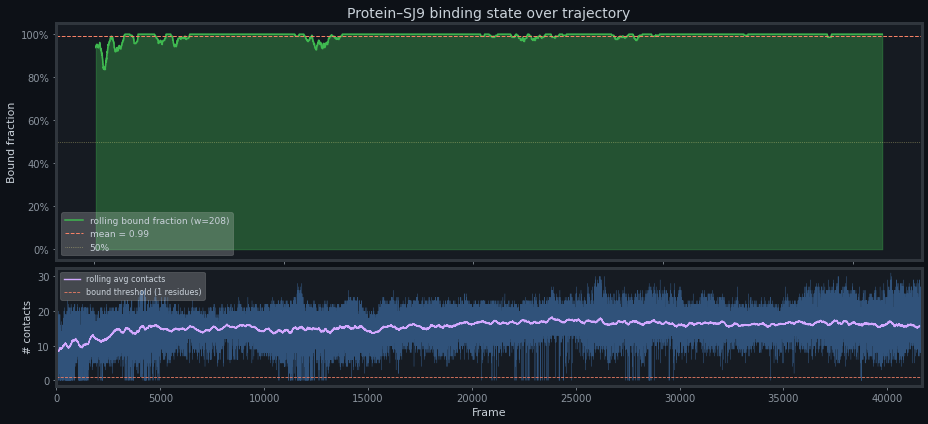

Saved → bound_fraction_over_time.png


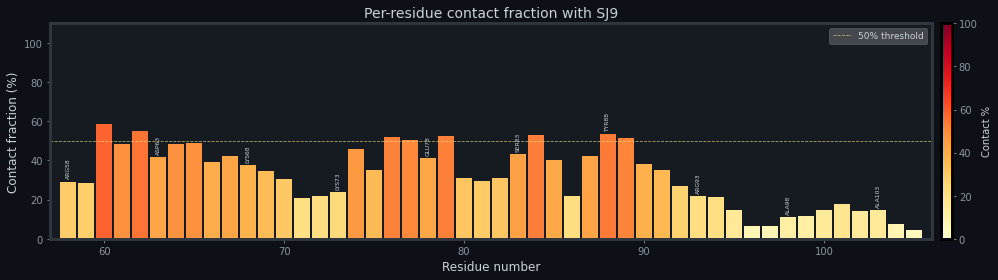

Saved → bound_fraction_per_residue.png

── Summary ──────────────────────────────────────────────
Cutoff:                        6.0 Å
Bound threshold:               ≥ 1 residue in contact (any heavy atom within 6.0 Å)
Global bound fraction:         0.993
Residues with >50% contact:    8
Residues with any contact:     48
Top 5 contact residues:
  TRP60     58.6%
  PHE62     55.0%
  TYR88     53.7%
  LEU84     52.9%
  VAL79     52.4%


In [40]:
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── 0. Inputs ────────────────────────────────────────────────────────────────
# Assumes `traj` (mdtraj.Trajectory) and `full_sequence` (list of 48 strings
# like ['ARG58', ..., 'GLU105']) are already in your namespace.

RESID_START      = 58      # first residue number in the protein
CUTOFF_NM        = 0.60    # 6.0 Å in nm (MDTraj uses nm throughout)
BOUND_MIN_CONTACTS = 1     # min residues in contact to call a frame "bound"

# ── 1. Select atom indices ────────────────────────────────────────────────────
# Get ligand (SJ9) heavy-atom indices
lig_indices = traj.topology.select("resname SJ9 and not element H")
print(f"Ligand heavy atoms: {len(lig_indices)}")

# Get protein heavy-atom indices, grouped by residue
# Use MDTraj's is_protein flag to exclude SJ9, water, ions, etc.
protein_residues = [res for res in traj.topology.residues
                    if res.is_protein]
n_residues = len(protein_residues)
print(f"Protein residues:   {n_residues}")

# Build list of heavy-atom index arrays, one per residue
residue_heavy_atoms = []
for res in protein_residues:
    atoms = [a.index for a in res.atoms if a.element.symbol != 'H']
    residue_heavy_atoms.append(np.array(atoms))

# ── 2. Compute per-residue, per-frame contacts ────────────────────────────────
# contact_matrix[frame, residue] = True if any heavy atom of that residue
# is within CUTOFF_NM of any ligand heavy atom.

# Strategy: compute a (n_frames, n_protein_heavy x n_lig_heavy) distance
# matrix is too large. Instead, batch over residues.

n_frames = traj.n_frames
contact_matrix = np.zeros((n_frames, n_residues), dtype=bool)

for res_idx, res_atoms in enumerate(residue_heavy_atoms):
    if len(res_atoms) == 0:
        continue
    # All atom pairs between this residue and the ligand
    pairs = np.array([[pa, la] for pa in res_atoms for la in lig_indices])
    # distances shape: (n_frames, n_pairs)
    dists = md.compute_distances(traj, pairs)
    # A contact exists in a frame if ANY pair is within cutoff
    contact_matrix[:, res_idx] = dists.min(axis=1) < CUTOFF_NM

print(f"Contact matrix computed: {contact_matrix.shape}  (frames × residues)")

# ── 3. Global bound/unbound per frame ────────────────────────────────────────
n_contacts_per_frame = contact_matrix.sum(axis=1)          # (n_frames,)
is_bound             = n_contacts_per_frame >= BOUND_MIN_CONTACTS  # (n_frames,)

global_bound_fraction = is_bound.mean()
print(f"\nGlobal bound fraction : {global_bound_fraction:.3f}  "
      f"({is_bound.sum()} / {n_frames} frames)")

# ── 4. Per-residue contact fraction ──────────────────────────────────────────
# Fraction of frames where each residue contacts the ligand
contact_fraction = contact_matrix.mean(axis=0)             # (n_residues,)

if len(full_sequence) != n_residues:
    raise ValueError(
        f"full_sequence length ({len(full_sequence)}) ≠ n_residues ({n_residues})"
    )

resid_numbers = list(range(RESID_START, RESID_START + n_residues))

df = pd.DataFrame({
    'Residue':          full_sequence,
    'ResID':            resid_numbers,
    'Contact_Fraction': contact_fraction,
    'Contact_%':        (contact_fraction * 100).round(1),
})

print("\nPer-residue contact fraction (top 10):")
print(df.nlargest(10, 'Contact_Fraction')[['Residue','ResID','Contact_%']].to_string(index=False))

df.to_csv('bound_fraction_per_residue.csv', index=False)
print("\nSaved → bound_fraction_per_residue.csv")

# ── 5. Plot A: global bound state over time ───────────────────────────────────
frames = np.arange(n_frames)
window = max(1, n_frames // 200)
rolling_bound = pd.Series(is_bound.astype(float)).rolling(window, center=True).mean()
rolling_contacts = pd.Series(n_contacts_per_frame.astype(float)).rolling(window, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 6),
                         gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')

# Top: rolling bound fraction
axes[0].fill_between(frames, rolling_bound, alpha=0.35, color='#3fb950')
axes[0].plot(frames, rolling_bound, color='#3fb950', lw=1.5,
             label=f'rolling bound fraction (w={window})')
axes[0].axhline(global_bound_fraction, color='#f78166', lw=1.0, ls='--',
                label=f'mean = {global_bound_fraction:.2f}')
axes[0].axhline(0.5, color='#f0e68c', lw=0.7, ls=':', alpha=0.6, label='50%')
axes[0].set_ylabel('Bound fraction', color='#c9d1d9', fontsize=11)
axes[0].set_title('Protein–SJ9 binding state over trajectory', color='#c9d1d9', fontsize=14)
axes[0].set_ylim(-0.05, 1.05)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axes[0].legend(framealpha=0.2, labelcolor='#c9d1d9', fontsize=9)
axes[0].tick_params(colors='#8b949e', labelbottom=False)
for sp in axes[0].spines.values(): sp.set_edgecolor('#30363d')

# Bottom: number of contacting residues
axes[1].plot(frames, n_contacts_per_frame, color='#58a6ff', lw=0.3, alpha=0.4)
axes[1].plot(frames, rolling_contacts, color='#d2a8ff', lw=1.4,
             label=f'rolling avg contacts')
axes[1].axhline(BOUND_MIN_CONTACTS, color='#f78166', lw=0.8, ls='--',
                label=f'bound threshold ({BOUND_MIN_CONTACTS} residues)')
axes[1].set_xlabel('Frame', color='#c9d1d9', fontsize=11)
axes[1].set_ylabel('# contacts', color='#c9d1d9', fontsize=10)
axes[1].set_xlim(0, n_frames - 1)
axes[1].legend(framealpha=0.2, labelcolor='#c9d1d9', fontsize=8)
axes[1].tick_params(colors='#8b949e')
for sp in axes[1].spines.values(): sp.set_edgecolor('#30363d')

plt.tight_layout(h_pad=0.4)
plt.savefig('bound_fraction_over_time.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → bound_fraction_over_time.png")

# ── 6. Plot B: per-residue contact fraction bar chart ────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 4))
fig2.patch.set_facecolor('#0d1117')
ax2.set_facecolor('#161b22')

cmap_vals = contact_fraction
bar_colors = plt.cm.YlOrRd(cmap_vals)

ax2.bar(df['ResID'], df['Contact_%'],
        color=bar_colors, edgecolor='none', width=0.85)

# Colour bar legend
sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                            norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2, pad=0.01, fraction=0.015)
cbar.set_label('Contact %', color='#c9d1d9', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')

# Annotate every 5th residue
for i, row in df.iterrows():
    if i % 5 == 0 and row['Contact_%'] > 1:
        ax2.text(row['ResID'], row['Contact_%'] + 1.5,
                 row['Residue'], ha='center', va='bottom',
                 color='#c9d1d9', fontsize=6, rotation=90)

ax2.axhline(50, color='#f0e68c', lw=0.8, ls='--', alpha=0.7, label='50% threshold')
ax2.set_xlabel('Residue number', color='#c9d1d9', fontsize=12)
ax2.set_ylabel('Contact fraction (%)', color='#c9d1d9', fontsize=12)
ax2.set_title('Per-residue contact fraction with SJ9', color='#c9d1d9', fontsize=14)
ax2.set_xlim(RESID_START - 1, RESID_START + n_residues)
ax2.set_ylim(0, 110)
ax2.tick_params(colors='#8b949e')
for sp in ax2.spines.values(): sp.set_edgecolor('#30363d')
ax2.legend(framealpha=0.2, labelcolor='#c9d1d9', fontsize=9)

plt.tight_layout()
plt.savefig('bound_fraction_per_residue.png', dpi=180, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print("Saved → bound_fraction_per_residue.png")

# ── 7. Summary ────────────────────────────────────────────────────────────────
print(f"\n── Summary ──────────────────────────────────────────────")
print(f"Cutoff:                        {CUTOFF_NM*10:.1f} Å")
print(f"Bound threshold:               ≥ {BOUND_MIN_CONTACTS} residue in contact (any heavy atom within {CUTOFF_NM*10:.1f} Å)")
print(f"Global bound fraction:         {global_bound_fraction:.3f}")
print(f"Residues with >50% contact:    {(contact_fraction > 0.5).sum()}")
print(f"Residues with any contact:     {(contact_fraction > 0.0).sum()}")
top = df.nlargest(5, 'Contact_Fraction')[['Residue','Contact_%']].values
print(f"Top 5 contact residues:")
for res, pct in top:
    print(f"  {res:8s}  {pct:.1f}%")

Helix 1 (62-66): 46.6 +/- 5.6%  (n=5 residues)
Helix 2 (75-80): 43.8 +/- 8.4%  (n=6 residues)
Helix 3 (86-88): 39.3 +/- 13.1%  (n=3 residues)


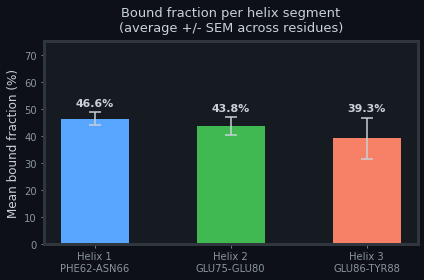

Saved -> helix_bound_fraction.png


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ── 0. Inputs ─────────────────────────────────────────────────────────────────
# Assumes `df` (from bound_fraction_analysis.py) is already in your namespace.
# df has columns: 'ResID', 'Contact_Fraction'

RESID_START = 58

helices = {
    'Helix 1': (62, 66),   # PHE62–ASN66
    'Helix 2': (75, 80),   # GLU75–GLU80
    'Helix 3': (86, 88),   # GLU86–TYR88
}

# ── 1. Average bound fraction per helix ───────────────────────────────────────
helix_names, helix_means, helix_sems = [], [], []

for name, (start, end) in helices.items():
    mask = (df['ResID'] >= start) & (df['ResID'] <= end)
    vals = df.loc[mask, 'Contact_Fraction'].values
    helix_names.append(name)
    helix_means.append(vals.mean() * 100)
    helix_sems.append(vals.std() / np.sqrt(len(vals)) * 100)
    print(f"{name} ({start}-{end}): {vals.mean()*100:.1f} +/- {vals.std()*100:.1f}%  "
          f"(n={len(vals)} residues)")

# ── 2. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors = ['#58a6ff', '#3fb950', '#f78166']
x      = np.arange(len(helix_names))
bars   = ax.bar(x, helix_means, yerr=helix_sems,
                color=colors, width=0.5, edgecolor='none',
                error_kw=dict(ecolor='#c9d1d9', lw=1.5, capsize=6, capthick=1.5))

# Value labels on top of each bar
for bar, mean, sem in zip(bars, helix_means, helix_sems):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + sem + 1.5,
            f'{mean:.1f}%',
            ha='center', va='bottom', color='#c9d1d9', fontsize=11, fontweight='bold')

# Two-line tick labels: "Helix N" on first line, residue range on second
range_labels = ['PHE62-ASN66', 'GLU75-GLU80', 'GLU86-TYR88']
ax.set_xticks(x)
ax.set_xticklabels([f'{n}\n{r}' for n, r in zip(helix_names, range_labels)],
                   color='#c9d1d9', fontsize=10)

ax.set_ylabel('Mean bound fraction (%)', color='#c9d1d9', fontsize=12)
ax.set_title('Bound fraction per helix segment\n(average +/- SEM across residues)',
             color='#c9d1d9', fontsize=13, pad=10)
ax.set_ylim(0, min(110, max(helix_means) * 1.4 + 10))
ax.tick_params(colors='#8b949e')
for sp in ax.spines.values():
    sp.set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig('helix_bound_fraction.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved -> helix_bound_fraction.png")

In [42]:
rg_300K = np.asarray(rg['rep:0'])

In [43]:
rg_300K.shape

(41652,)

In [44]:
rg_300k = np.array(rg['rep:0'])

import numpy as np
import pyblock

rg = np.asarray(rg_300k)

block_data = pyblock.blocking.reblock(rg)
opt = pyblock.blocking.find_optimal_block(len(rg), block_data)
opt_idx = max(opt)

chosen = block_data[opt_idx]

mean = chosen.mean
error = chosen.std_err

print(f"Naive mean: {rg.mean():.4f}")
print(f"Block mean: {mean:.4f}")
print(f"Block error: {error:.4f}")

Naive mean: 1.4350
Block mean: 1.4349
Block error: 0.0047


In [45]:
bf_kd

{'rep:0': [0.0257, 0.0051],
 'rep:1': [0.0265, 0.005],
 'rep:2': [0.0247, 0.0049],
 'rep:3': [0.0292, 0.0056],
 'rep:4': [0.0335, 0.0053],
 'rep:5': [0.0418, 0.0068],
 'rep:6': [0.0453, 0.0073],
 'rep:7': [0.0533, 0.008],
 'rep:8': [0.0591, 0.0084],
 'rep:9': [0.0773, 0.0144],
 'rep:10': [0.0859, 0.0154],
 'rep:11': [0.1029, 0.0178],
 'rep:12': [0.1116, 0.0197],
 'rep:13': [0.1311, 0.0309],
 'rep:14': [0.1508, 0.0347],
 'rep:15': [0.1712, 0.0415],
 'rep:16': [0.1712, 0.0415],
 'rep:17': [0.1712, 0.0415],
 'rep:18': [0.1712, 0.0415],
 'rep:19': [0.1712, 0.0415],
 'demux:0': [0.1093, 0.0331],
 'demux:1': [0.0426, 0.0099],
 'demux:2': [0.0486, 0.0069],
 'demux:3': [0.1255, 0.0354],
 'demux:4': [0.061, 0.0086],
 'demux:5': [0.0861, 0.0292],
 'demux:6': [0.0793, 0.0163],
 'demux:7': [0.0768, 0.0265],
 'demux:8': [0.0602, 0.008],
 'demux:9': [0.0617, 0.0084],
 'demux:10': [0.0526, 0.0076],
 'demux:11': [0.0495, 0.008],
 'demux:12': [0.0436, 0.0068],
 'demux:13': [0.0683, 0.0125],
 'demux:14'